<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Forecast_SalesPrice_with_missing_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import pandas as pd

#dataset_url = 'https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Data%20Preparation/ames_housing_data_hard_rand.csv'
#dataset_url = 'https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Data%20Preparation/ames_housing_data_hard.csv'
#dataset_url = 'https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Data%20Preparation/ames_housing_data_hard_NOTrand.csv'
dataset_url = 'https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Data%20Preparation/ames_housing_data_NoMissing.csv'

try:
    df = pd.read_csv(dataset_url)
    print("Dataset loaded successfully from URL.")
except Exception as e:
    print(f"Error loading dataset from URL: {e}")
    df = None

# Display the first 5 rows of the DataFrame
if df is not None:
    print("\nFirst 5 rows of the dataset:\n\n")
    display(df.head())
    df.info()
    print("\n\nDescriptive Statistics:\n")
    display(df.describe())

Dataset loaded successfully from URL.

First 5 rows of the dataset:




,Order,MS Zoning,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
0,1,RL,1960,6,5,31770,528.0,0,3,1,7,215000
1,2,RH,1961,5,6,11622,730.0,0,2,1,5,105000
2,3,RL,1958,6,6,14267,312.0,0,3,1,6,172000
3,4,RL,1968,7,5,11160,522.0,0,3,2,8,244000
4,5,RL,1997,5,5,13830,482.0,0,3,2,6,189900


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2929 entries, 0 to 2928
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order          2929 non-null   int64  
 1   MS Zoning      2929 non-null   object 
 2   Year Built     2929 non-null   int64  
 3   Overall Qual   2929 non-null   int64  
 4   Overall Cond   2929 non-null   int64  
 5   Lot Area       2929 non-null   int64  
 6   Garage Area    2929 non-null   float64
 7   Pool Area      2929 non-null   int64  
 8   Bedroom AbvGr  2929 non-null   int64  
 9   Full Bath      2929 non-null   int64  
 10  TotRms AbvGrd  2929 non-null   int64  
 11  SalePrice      2929 non-null   int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 274.7+ KB


Descriptive Statistics:



,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
count,2929.00000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000
mean,1465.23660,1971.372823,6.095254,5.562991,10148.293274,472.819734,2.244111,2.854216,1.566405,6.443155,180806.263913
std,845.98674,30.237318,1.411122,1.111697,7881.337623,215.046549,35.603235,0.827868,0.552977,1.573212,79898.423323
min,1.00000,1872.000000,1.000000,1.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12789.000000
25%,733.00000,1954.000000,5.000000,5.000000,7440.000000,320.000000,0.000000,2.000000,1.000000,5.000000,129500.000000
50%,1465.00000,1973.000000,6.000000,5.000000,9439.000000,480.000000,0.000000,3.000000,2.000000,6.000000,160000.000000
75%,2197.00000,2001.000000,7.000000,6.000000,11556.000000,576.000000,0.000000,3.000000,2.000000,7.000000,213500.000000
max,2930.00000,2010.000000,10.000000,9.000000,215245.000000,1488.000000,800.000000,8.000000,4.000000,15.000000,755000.000000


### Missing Value Analysis

Now, let's analyze the missing values in the dataset. This will show us which columns have missing data and how many.

In [93]:
if df is not None:
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})

    print("\nMissing values in each column:")
    # Filter to show only columns with missing values and sort them
    display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

    if missing_df['Missing Count'].sum() == 0:
        print("No missing values found in the dataset.")


Missing values in each column:


,Missing Count,Missing Percentage


No missing values found in the dataset.


### Bivariate Analysis of Missing 'Full Bath' Values

Let's investigate if the missing values in the 'Full Bath' column are related to other attributes in the dataset. We'll create a new indicator column for missing 'Full Bath' and visualize its relationship with other features.

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    # Create a boolean column indicating if 'Full Bath' is missing
    df['is_full_bath_missing'] = df['Full Bath'].isnull()
    print("Added 'is_full_bath_missing' column to the DataFrame.")
    display(df[['Full Bath', 'is_full_bath_missing']].head())
else:
    print("DataFrame 'df' is not available.")

Added 'is_full_bath_missing' column to the DataFrame.


,Full Bath,is_full_bath_missing
0,1,False
1,1,False
2,1,False
3,2,False
4,2,False


#### Missing 'Full Bath' by 'MS Zoning' (Categorical Feature)

We'll use a bar chart to count the number of missing 'Full Bath' values for each category within the 'MS Zoning' column.

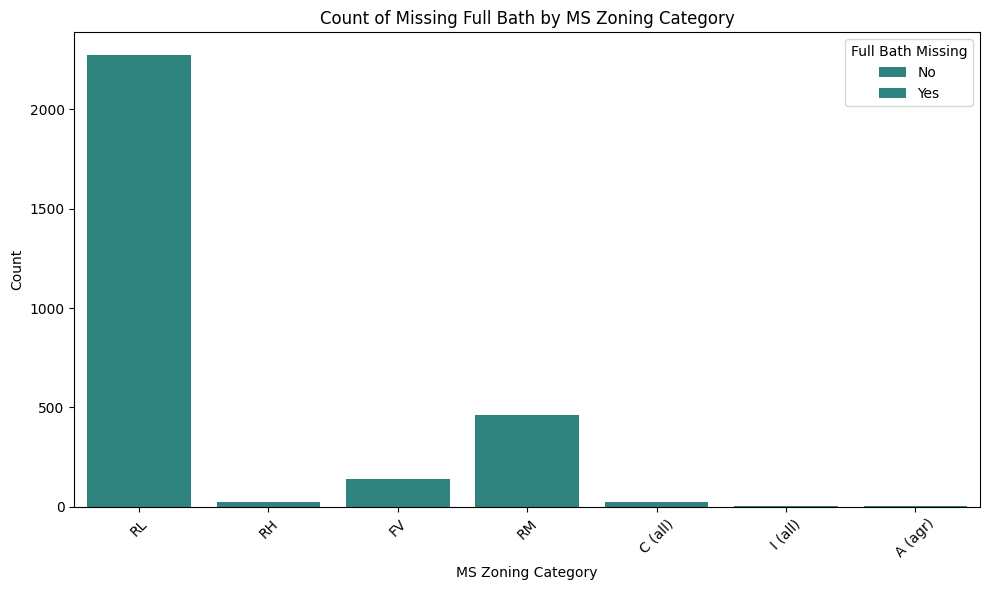

In [95]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='MS Zoning', hue='is_full_bath_missing', data=df, palette='viridis')
    plt.title('Count of Missing Full Bath by MS Zoning Category')
    plt.xlabel('MS Zoning Category')
    plt.ylabel('Count')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

#### Missing 'Full Bath' and 'Lot Area' (Numerical Feature)

For numerical features like 'Lot Area', a direct bar chart of missing counts isn't ideal. Instead, we'll visualize the distribution of 'Lot Area' for rows where 'Full Bath' is missing versus where it's present, using Kernel Density Estimate (KDE) plots. This helps us see if 'Full Bath' tends to be missing for specific 'Lot Area' ranges.

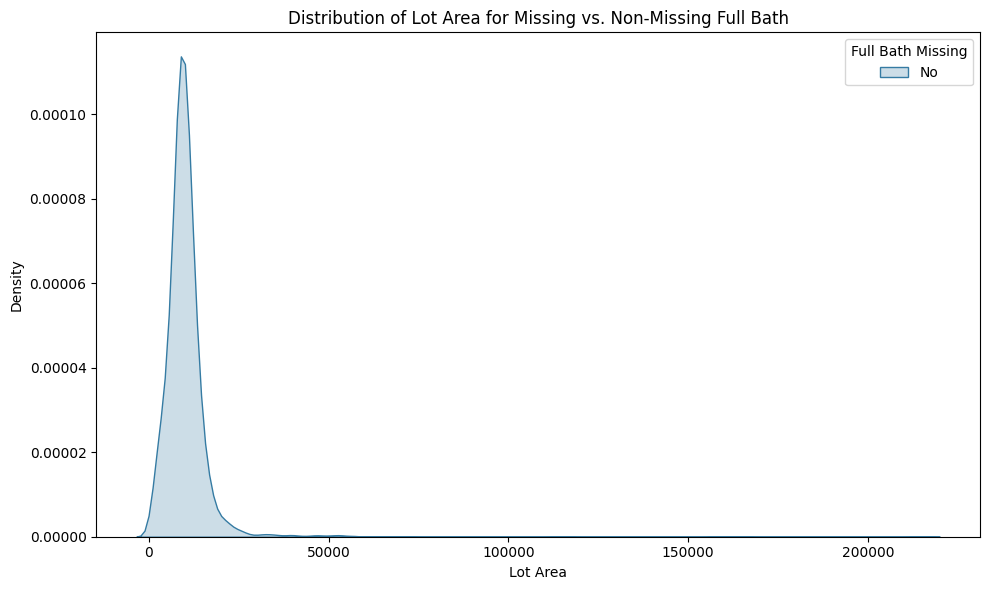

In [96]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x='Lot Area', hue='is_full_bath_missing', fill=True, common_norm=False, palette='mako')
    plt.title('Distribution of Lot Area for Missing vs. Non-Missing Full Bath')
    plt.xlabel('Lot Area')
    plt.ylabel('Density')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

#### Missing 'Full Bath' and 'Year Built' (Numerical Feature)

Similarly, let's look at the distribution of 'Year Built' for rows with and without missing 'Full Bath' values.

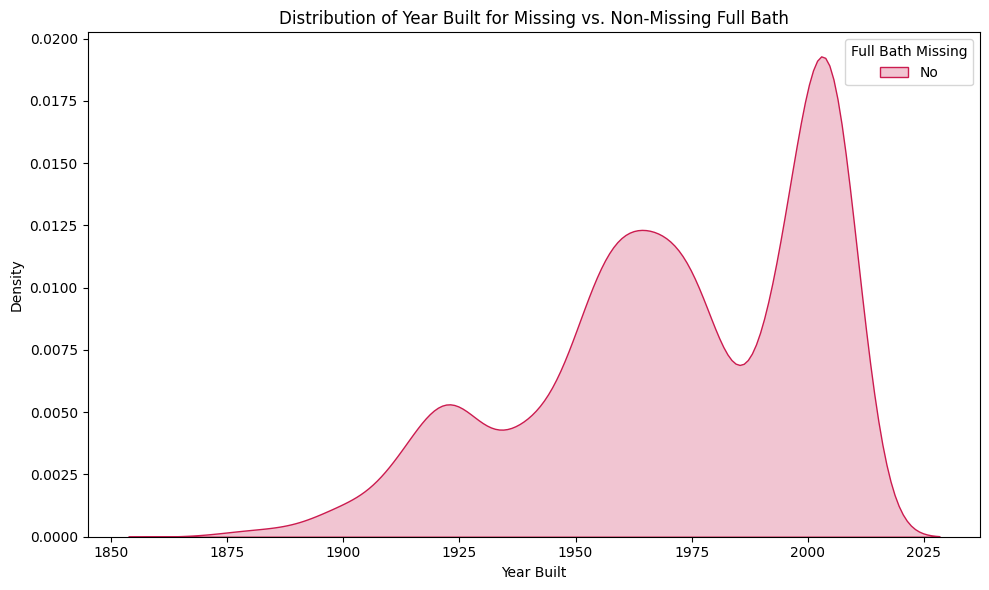

In [97]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x='Year Built', hue='is_full_bath_missing', fill=True, common_norm=False, palette='rocket')
    plt.title('Distribution of Year Built for Missing vs. Non-Missing Full Bath')
    plt.xlabel('Year Built')
    plt.ylabel('Density')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

#### Missing 'Overall Qual' Analysis

Let's analyze the distribution of 'Overall Qual' values and how its missingness relates to other features.

### Pearson Correlation Matrix

Let's compute the Pearson correlation matrix for the numerical attributes in the dataset to understand the relationships between them. A heatmap will be used for visualization.

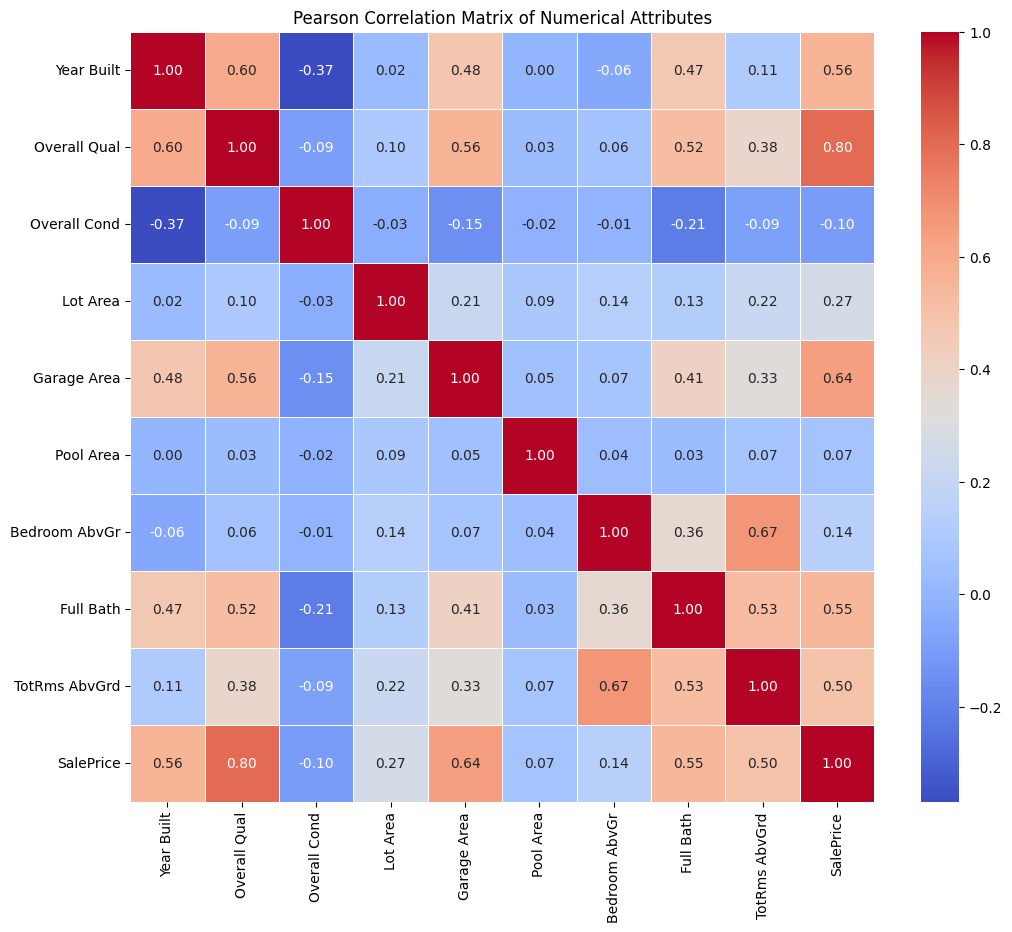

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    # Select only numerical columns for correlation calculation
    numerical_df = df.select_dtypes(include=['int64', 'float64'])

    # Drop the 'Order' column if it exists, as it's an identifier
    if 'Order' in numerical_df.columns:
        numerical_df = numerical_df.drop(columns=['Order'])

    # Also drop the 'is_full_bath_missing' column if it exists, as it's an indicator variable
    if 'is_full_bath_missing' in numerical_df.columns:
        numerical_df = numerical_df.drop(columns=['is_full_bath_missing'])

    # Calculate the Pearson correlation matrix
    correlation_matrix = numerical_df.corr(method='pearson')

    # Plot the heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Pearson Correlation Matrix of Numerical Attributes')
    plt.show()
else:
    print("DataFrame 'df' is not available to calculate correlation matrix.")

### Data Preprocessing for Model Training

We will begin by one-hot encoding all categorical features. Then, we will address missing numerical values using a Random Forest-based imputation method. This involves iteratively training a Random Forest model to predict missing values in one column based on the non-missing values in other columns. Finally, we will drop the `Order` and `is_full_bath_missing` columns.

In [99]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

if df is not None:
    # Create a copy to avoid modifying the original DataFrame directly
    df_processed = df.copy()

    # Drop the 'is_full_bath_missing' as it's an indicator
    if 'is_full_bath_missing' in df_processed.columns:
        df_processed = df_processed.drop(columns=['is_full_bath_missing'])

    # Identify all categorical columns for one-hot encoding
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
        print(f"One-hot encoded {len(categorical_cols)} categorical columns.")
    else:
        df_encoded = df_processed
        print("No categorical columns to encode.")

    print("Shape of DataFrame after one-hot encoding:", df_encoded.shape)
    display(df_encoded.head())


One-hot encoded 1 categorical columns.
Shape of DataFrame after one-hot encoding: (2929, 17)


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
0,1,1960,6,5,31770,528.0,0,3,1,7,215000,False,False,False,False,True,False
1,2,1961,5,6,11622,730.0,0,2,1,5,105000,False,False,False,True,False,False
2,3,1958,6,6,14267,312.0,0,3,1,6,172000,False,False,False,False,True,False
3,4,1968,7,5,11160,522.0,0,3,2,8,244000,False,False,False,False,True,False
4,5,1997,5,5,13830,482.0,0,3,2,6,189900,False,False,False,False,True,False


In [100]:
if df_encoded is not None:
    missing_values = df_encoded.isnull().sum()
    missing_percentage = (df_encoded.isnull().sum() / len(df_encoded)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})

    print("\nMissing values in each column:")
    # Filter to show only columns with missing values and sort them
    display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

    if missing_df['Missing Count'].sum() == 0:
        print("No missing values found in the dataset.")


Missing values in each column:


,Missing Count,Missing Percentage


No missing values found in the dataset.


In [101]:
from sklearn.model_selection import train_test_split

if 'df_encoded' in locals() and df_encoded is not None:
    # Separate features (X) and target (y)
    X_base = df_encoded.drop('SalePrice', axis=1)
    y_base = df_encoded['SalePrice']

    # Perform initial train-test split before any imputation
    X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

    print("Initial train-test split performed on df_encoded:")
    print(f"X_train_base shape: {X_train_base.shape}")
    print(f"X_test_base shape: {X_test_base.shape}")
    print(f"y_train_base shape: {y_train_base.shape}")
    print(f"y_test_base shape: {y_test_base.shape}")
else:
    print("DataFrame 'df_encoded' is not available for initial split.")

Initial train-test split performed on df_encoded:
X_train_base shape: (2343, 16)
X_test_base shape: (586, 16)
y_train_base shape: (2343,)
y_test_base shape: (586,)


### XGBoost Regressor Training (without explicit imputation)

In [102]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

if 'df_encoded' in locals() and df_encoded is not None:
    # Initialize and train the XGBoost Regressor model
    # tree_method='hist' for faster training with missing value support
    # n_jobs=-1 to use all available cores
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model.fit(X_train_base, y_train_base)
    print("XGBoost Regressor model trained successfully without explicit imputation.")

    # Make predictions on the test set
    y_pred_xgb = xgb_model.predict(X_test_base)

    # Evaluate the model
    r2_xgb = r2_score(y_test_base, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test_base, y_pred_xgb)

    print(f"\nXGBoost R-squared: {r2_xgb:.4f}")
    print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")

    # Display feature importances
    feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_base.columns)
    print("\nTop 10 XGBoost Feature Importances:")
    display(feature_importances_xgb.nlargest(10))
else:
    print("DataFrame 'df_encoded' is not available for XGBoost model training.")

XGBoost Regressor model trained successfully without explicit imputation.

XGBoost R-squared: 0.8476
XGBoost Mean Squared Error: 1148601856.00

Top 10 XGBoost Feature Importances:


,0
Overall Qual,0.606483
Full Bath,0.117389
MS Zoning_RL,0.051208
Pool Area,0.050086
MS Zoning_RM,0.034282
TotRms AbvGrd,0.027094
Lot Area,0.023945
Bedroom AbvGr,0.019598
Garage Area,0.019534
Overall Cond,0.015736


### Mean Imputation on `df_encoded`

Now, let's perform mean imputation on the `df_encoded` DataFrame. This will fill any remaining `NaN` values in numerical columns with the mean of that column. The result will be stored in a new DataFrame named `df_mean`.

In [103]:
from sklearn.impute import SimpleImputer

if 'X_train_base' in locals() and X_train_base is not None and\
   'X_test_base' in locals() and X_test_base is not None:
    X_train_mean = X_train_base.copy()
    X_test_mean = X_test_base.copy()

    # Identify numerical columns with missing values in the training set
    numerical_cols_with_missing_train = X_train_mean.select_dtypes(include=['int64', 'float64']).columns[X_train_mean.select_dtypes(include=['int64', 'float64']).isnull().any()].tolist()

    if numerical_cols_with_missing_train:
        # Initialize SimpleImputer with mean strategy
        imputer_mean = SimpleImputer(strategy='mean')

        # Fit the imputer ONLY on the training data
        imputer_mean.fit(X_train_mean[numerical_cols_with_missing_train])

        # Transform both training and test data
        X_train_mean[numerical_cols_with_missing_train] = imputer_mean.transform(X_train_mean[numerical_cols_with_missing_train])
        X_test_mean[numerical_cols_with_missing_train] = imputer_mean.transform(X_test_mean[numerical_cols_with_missing_train])
        print(f"Successfully imputed missing values in training and test sets using mean strategy for columns: {numerical_cols_with_missing_train}")
    else:
        print("No numerical columns with missing values to impute in the training set.")

    # Verify no more missing values in the imputed sets
    if X_train_mean.isnull().sum().sum() == 0 and X_test_mean.isnull().sum().sum() == 0:
        print("\nAll missing values handled in X_train_mean and X_test_mean after mean imputation.")
    else:
        print("\nWarning: Some missing values still exist after processing. Details:")
        print("Missing in X_train_mean:")
        display(X_train_mean.isnull().sum()[X_train_mean.isnull().sum() > 0])
        print("Missing in X_test_mean:")
        display(X_test_mean.isnull().sum()[X_test_mean.isnull().sum() > 0])

    print("\nShape of X_train_mean after mean imputation:", X_train_mean.shape)
    display(X_train_mean.head())
    print("\nShape of X_test_mean after mean imputation:", X_test_mean.shape)
    display(X_test_mean.head())
else:
    print("X_train_base or X_test_base is not available for mean imputation.")

No numerical columns with missing values to impute in the training set.

All missing values handled in X_train_mean and X_test_mean after mean imputation.

Shape of X_train_mean after mean imputation: (2343, 16)


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
2555,2557,1926,4,5,5825,528.0,0,1,1,5,False,False,False,False,True,False
2624,2626,1949,3,4,8544,400.0,0,2,2,6,False,False,False,False,True,False
677,678,1950,6,5,8064,900.0,0,3,1,5,False,False,False,False,True,False
746,747,1925,5,5,8635,1184.0,0,2,1,5,False,False,False,False,False,True
2339,2341,2005,8,5,11302,758.0,0,3,2,7,False,False,False,False,True,False



Shape of X_test_mean after mean imputation: (586, 16)


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
1472,1473,2002,7,5,9135,532.0,0,3,2,7,False,False,False,False,True,False
2178,2179,2005,5,5,7024,450.0,0,2,1,5,False,False,False,False,True,False
368,369,2005,7,5,16158,430.0,0,3,2,7,False,False,False,False,True,False
2614,2616,1961,6,6,10800,418.0,0,3,2,6,False,False,False,False,True,False
1818,1819,1977,5,5,6285,308.0,0,2,1,5,False,False,False,False,True,False


XGBoost Regressor Training (with Mean imputation)

In [104]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

# Check for existence of imputed dataframes
if 'X_train_mean' in locals() and X_train_mean is not None and \
   'X_test_mean' in locals() and X_test_mean is not None and \
   'y_train_base' in locals() and y_train_base is not None and \
   'y_test_base' in locals() and y_test_base is not None:

    print("Using mean-imputed data for XGBoost training and evaluation.")
    print(f"Training features shape: {X_train_mean.shape}")
    print(f"Testing features shape: {X_test_mean.shape}")

    # Initialize and train the XGBoost Regressor model
    xgb_model_mean = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model_mean.fit(X_train_mean, y_train_base) # Use X_train_mean and y_train_base
    print("XGBoost Regressor model trained successfully with mean imputation.")

    # Make predictions on the test set
    y_pred_xgb_mean = xgb_model_mean.predict(X_test_mean) # Use X_test_mean

    # Evaluate the model
    r2_xgb_mean = r2_score(y_test_base, y_pred_xgb_mean) # Use y_test_base
    mse_xgb_mean = mean_squared_error(y_test_base, y_pred_xgb_mean) # Use y_test_base

    print(f"\nXGBoost (Mean Imputation) R-squared: {r2_xgb_mean:.4f}")
    print(f"XGBoost (Mean Imputation) Mean Squared Error: {mse_xgb_mean:.2f}")

    # Display feature importances
    feature_importances_xgb_mean = pd.Series(xgb_model_mean.feature_importances_, index=X_train_mean.columns)
    print("\nTop 10 XGBoost (Mean Imputation) Feature Importances:")
    display(feature_importances_xgb_mean.nlargest(10))
else:
    print("Mean-imputed DataFrames (X_train_mean, X_test_mean, y_train_base, y_test_base) are not available for XGBoost model training.")

Using mean-imputed data for XGBoost training and evaluation.
Training features shape: (2343, 16)
Testing features shape: (586, 16)
XGBoost Regressor model trained successfully with mean imputation.

XGBoost (Mean Imputation) R-squared: 0.8476
XGBoost (Mean Imputation) Mean Squared Error: 1148601856.00

Top 10 XGBoost (Mean Imputation) Feature Importances:


,0
Overall Qual,0.606483
Full Bath,0.117389
MS Zoning_RL,0.051208
Pool Area,0.050086
MS Zoning_RM,0.034282
TotRms AbvGrd,0.027094
Lot Area,0.023945
Bedroom AbvGr,0.019598
Garage Area,0.019534
Overall Cond,0.015736


### Random Forest Imputation on `df_encoded`

Let's perform Random Forest imputation on the `df_encoded` DataFrame to handle its missing numerical values. The result will be stored in a new DataFrame named `df_rf`.

In [105]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

if 'X_train_base' in locals() and X_train_base is not None and\
   'X_test_base' in locals() and X_test_base is not None:
    print("\nStarting Random Forest imputation for missing numerical values...")
    X_train_rf = X_train_base.copy()
    X_test_rf = X_test_base.copy()

    # Identify numerical columns with missing values in the training set
    cols_with_missing_train = X_train_rf.select_dtypes(include=['int64', 'float64']).columns[X_train_rf.select_dtypes(include=['int64', 'float64']).isnull().any()].tolist()

    if cols_with_missing_train:
        # Create a combined DataFrame for feature selection for the imputer (training data only)
        # We need to impute column by column
        for col_to_impute in cols_with_missing_train:
            print(f"  Imputing missing values in column: '{col_to_impute}'")

            # Prepare data for imputer training (only from X_train_rf)
            # Features are all other columns in X_train_rf (excluding the target col_to_impute)
            # and only non-null rows for the col_to_impute
            df_observed_train = X_train_rf.dropna(subset=[col_to_impute])
            X_impute_train = df_observed_train.drop(columns=[col_to_impute])
            y_impute_train = df_observed_train[col_to_impute]

            # Select features for imputation, ensuring they have no NaNs in the training part
            features_for_imputation = X_impute_train.columns[X_impute_train.isnull().sum() == 0].tolist()

            if not features_for_imputation:
                # Fallback to mean imputation if no clean features are available for RF
                mean_val = df_observed_train[col_to_impute].mean()
                X_train_rf.loc[X_train_rf[col_to_impute].isnull(), col_to_impute] = mean_val
                X_test_rf.loc[X_test_rf[col_to_impute].isnull(), col_to_impute] = mean_val # Apply to test set as well
                print(f"    (Falling back to mean imputation for '{col_to_impute}' due to no clean features: {mean_val:.2f})")
                continue

            rf_imputer = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
            rf_imputer.fit(X_impute_train[features_for_imputation], y_impute_train)

            # Impute missing values in the training set
            missing_rows_train_idx = X_train_rf[X_train_rf[col_to_impute].isnull()].index
            if not missing_rows_train_idx.empty:
                X_impute_predict_train = X_train_rf.loc[missing_rows_train_idx, features_for_imputation]
                # Drop rows from X_impute_predict_train if they have NaNs in features_for_imputation
                valid_predict_train_idx = X_impute_predict_train.dropna().index
                if not valid_predict_train_idx.empty:
                    predicted_values_train = rf_imputer.predict(X_impute_predict_train.loc[valid_predict_train_idx])
                    X_train_rf.loc[valid_predict_train_idx, col_to_impute] = predicted_values_train
                    print(f"    Successfully imputed {len(predicted_values_train)} values for '{col_to_impute}' in training set.")
                else:
                    print(f"    No valid rows to predict for '{col_to_impute}' in training set after dropping NaNs in features.")
            else:
                print(f"    No missing values in '{col_to_impute}' in training set to impute.")

            # Impute missing values in the test set using the *trained* imputer
            missing_rows_test_idx = X_test_rf[X_test_rf[col_to_impute].isnull()].index
            if not missing_rows_test_idx.empty:
                X_impute_predict_test = X_test_rf.loc[missing_rows_test_idx, features_for_imputation]
                # Drop rows from X_impute_predict_test if they have NaNs in features_for_imputation
                valid_predict_test_idx = X_impute_predict_test.dropna().index
                if not valid_predict_test_idx.empty:
                    predicted_values_test = rf_imputer.predict(X_impute_predict_test.loc[valid_predict_test_idx])
                    X_test_rf.loc[valid_predict_test_idx, col_to_impute] = predicted_values_test
                    print(f"    Successfully imputed {len(predicted_values_test)} values for '{col_to_impute}' in test set.")
                else:
                    print(f"    No valid rows to predict for '{col_to_impute}' in test set after dropping NaNs in features.")
            else:
                print(f"    No missing values in '{col_to_impute}' in test set to impute.")
    else:
        print("No numerical columns with missing values to impute in the training set.")

    # Verify no more missing values
    if X_train_rf.isnull().sum().sum() == 0 and X_test_rf.isnull().sum().sum() == 0:
        print("\nAll missing values handled after Random Forest imputation for training and test sets.")
    else:
        print("\nWarning: Some missing values still exist after processing. Details:")
        print("Missing in X_train_rf:")
        display(X_train_rf.isnull().sum()[X_train_rf.isnull().sum() > 0])
        print("Missing in X_test_rf:")
        display(X_test_rf.isnull().sum()[X_test_rf.isnull().sum() > 0])


    print("Shape of X_train_rf after Random Forest imputation:", X_train_rf.shape)
    display(X_train_rf.head())
    print("Shape of X_test_rf after Random Forest imputation:", X_test_rf.shape)
    display(X_test_rf.head())
else:
    print("X_train_base or X_test_base is not available for Random Forest imputation.")


Starting Random Forest imputation for missing numerical values...
No numerical columns with missing values to impute in the training set.

All missing values handled after Random Forest imputation for training and test sets.
Shape of X_train_rf after Random Forest imputation: (2343, 16)


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
2555,2557,1926,4,5,5825,528.0,0,1,1,5,False,False,False,False,True,False
2624,2626,1949,3,4,8544,400.0,0,2,2,6,False,False,False,False,True,False
677,678,1950,6,5,8064,900.0,0,3,1,5,False,False,False,False,True,False
746,747,1925,5,5,8635,1184.0,0,2,1,5,False,False,False,False,False,True
2339,2341,2005,8,5,11302,758.0,0,3,2,7,False,False,False,False,True,False


Shape of X_test_rf after Random Forest imputation: (586, 16)


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
1472,1473,2002,7,5,9135,532.0,0,3,2,7,False,False,False,False,True,False
2178,2179,2005,5,5,7024,450.0,0,2,1,5,False,False,False,False,True,False
368,369,2005,7,5,16158,430.0,0,3,2,7,False,False,False,False,True,False
2614,2616,1961,6,6,10800,418.0,0,3,2,6,False,False,False,False,True,False
1818,1819,1977,5,5,6285,308.0,0,2,1,5,False,False,False,False,True,False


XGBoost Regressor Training (with Rando Forest imputation)

In [106]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

# Check for existence of imputed dataframes
if 'X_train_rf' in locals() and X_train_rf is not None and \
   'X_test_rf' in locals() and X_test_rf is not None and \
   'y_train_base' in locals() and y_train_base is not None and \
   'y_test_base' in locals() and y_test_base is not None:

    print("Using Random Forest-imputed data for XGBoost training and evaluation.")
    print(f"Training features shape: {X_train_rf.shape}")
    print(f"Testing features shape: {X_test_rf.shape}")

    # Initialize and train the XGBoost Regressor model
    xgb_model_rf = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model_rf.fit(X_train_rf, y_train_base) # Use X_train_rf and y_train_base
    print("XGBoost Regressor model trained successfully with Random Forest imputation.")

    # Make predictions on the test set
    y_pred_xgb_rf = xgb_model_rf.predict(X_test_rf) # Use X_test_rf

    # Evaluate the model
    r2_xgb_rf = r2_score(y_test_base, y_pred_xgb_rf) # Use y_test_base
    mse_xgb_rf = mean_squared_error(y_test_base, y_pred_xgb_rf) # Use y_test_base

    print(f"\nXGBoost (Random Forest Imputation) R-squared: {r2_xgb_rf:.4f}")
    print(f"XGBoost (Random Forest Imputation) Mean Squared Error: {mse_xgb_rf:.2f}")

    # Display feature importances
    feature_importances_xgb_rf = pd.Series(xgb_model_rf.feature_importances_, index=X_train_rf.columns)
    print("\nTop 10 XGBoost (Random Forest Imputation) Feature Importances:")
    display(feature_importances_xgb_rf.nlargest(10))
else:
    print("Random Forest-imputed DataFrames (X_train_rf, X_test_rf, y_train_base, y_test_base) are not available for XGBoost model training.")

Using Random Forest-imputed data for XGBoost training and evaluation.
Training features shape: (2343, 16)
Testing features shape: (586, 16)
XGBoost Regressor model trained successfully with Random Forest imputation.

XGBoost (Random Forest Imputation) R-squared: 0.8476
XGBoost (Random Forest Imputation) Mean Squared Error: 1148601856.00

Top 10 XGBoost (Random Forest Imputation) Feature Importances:


,0
Overall Qual,0.606483
Full Bath,0.117389
MS Zoning_RL,0.051208
Pool Area,0.050086
MS Zoning_RM,0.034282
TotRms AbvGrd,0.027094
Lot Area,0.023945
Bedroom AbvGr,0.019598
Garage Area,0.019534
Overall Cond,0.015736


### K-Nearest Neighbors (KNN) Imputation on `df_encoded`

Let's perform K-Nearest Neighbors (KNN) imputation on the `df_encoded` DataFrame to handle its missing numerical values. This method imputes missing values by finding the `n_neighbors` closest samples in the training set and averaging their values. The result will be stored in a new DataFrame named `df_knn`.

In [107]:
import pandas as pd
from sklearn.impute import KNNImputer

if 'X_train_base' in locals() and X_train_base is not None and \
   'X_test_base' in locals() and X_test_base is not None:
    print("\nStarting K-Nearest Neighbors (KNN) imputation for missing numerical values...")
    X_train_knn = X_train_base.copy()
    X_test_knn = X_test_base.copy()

    # Identify numerical columns with missing values in the training set
    numerical_cols_with_missing_train = X_train_knn.select_dtypes(include=['int64', 'float64']).columns[X_train_knn.select_dtypes(include=['int64', 'float64']).isnull().any()].tolist()

    if numerical_cols_with_missing_train:
        # Initialize KNNImputer
        imputer_knn = KNNImputer(n_neighbors=5)

        # Fit the imputer ONLY on the training data
        imputer_knn.fit(X_train_knn[numerical_cols_with_missing_train])

        # Transform both training and test data
        X_train_knn[numerical_cols_with_missing_train] = imputer_knn.transform(X_train_knn[numerical_cols_with_missing_train])
        X_test_knn[numerical_cols_with_missing_train] = imputer_knn.transform(X_test_knn[numerical_cols_with_missing_train])
        print(f"Successfully imputed missing values in training and test sets using KNN strategy for columns: {numerical_cols_with_missing_train}")
    else:
        print("No numerical columns with missing values to impute in the training set.")

    # Verify no more missing values in the imputed sets
    if X_train_knn.isnull().sum().sum() == 0 and X_test_knn.isnull().sum().sum() == 0:
        print("\nAll missing values handled in X_train_knn and X_test_knn after KNN imputation.")
    else:
        print("\nWarning: Some missing values still exist after processing. Details:")
        print("Missing in X_train_knn:")
        display(X_train_knn.isnull().sum()[X_train_knn.isnull().sum() > 0])
        print("Missing in X_test_knn:")
        display(X_test_knn.isnull().sum()[X_test_knn.isnull().sum() > 0])

    print("Shape of X_train_knn after KNN imputation:", X_train_knn.shape)
    display(X_train_knn.head())
    print("Shape of X_test_knn after KNN imputation:", X_test_knn.shape)
    display(X_test_knn.head())
else:
    print("X_train_base or X_test_base is not available for KNN imputation.")


Starting K-Nearest Neighbors (KNN) imputation for missing numerical values...
No numerical columns with missing values to impute in the training set.

All missing values handled in X_train_knn and X_test_knn after KNN imputation.
Shape of X_train_knn after KNN imputation: (2343, 16)


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
2555,2557,1926,4,5,5825,528.0,0,1,1,5,False,False,False,False,True,False
2624,2626,1949,3,4,8544,400.0,0,2,2,6,False,False,False,False,True,False
677,678,1950,6,5,8064,900.0,0,3,1,5,False,False,False,False,True,False
746,747,1925,5,5,8635,1184.0,0,2,1,5,False,False,False,False,False,True
2339,2341,2005,8,5,11302,758.0,0,3,2,7,False,False,False,False,True,False


Shape of X_test_knn after KNN imputation: (586, 16)


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
1472,1473,2002,7,5,9135,532.0,0,3,2,7,False,False,False,False,True,False
2178,2179,2005,5,5,7024,450.0,0,2,1,5,False,False,False,False,True,False
368,369,2005,7,5,16158,430.0,0,3,2,7,False,False,False,False,True,False
2614,2616,1961,6,6,10800,418.0,0,3,2,6,False,False,False,False,True,False
1818,1819,1977,5,5,6285,308.0,0,2,1,5,False,False,False,False,True,False


In [108]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

# Check for existence of imputed dataframes
if 'X_train_knn' in locals() and X_train_knn is not None and \
   'X_test_knn' in locals() and X_test_knn is not None and \
   'y_train_base' in locals() and y_train_base is not None and \
   'y_test_base' in locals() and y_test_base is not None:

    print("Using KNN-imputed data for XGBoost training and evaluation.")
    print(f"Training features shape: {X_train_knn.shape}")
    print(f"Testing features shape: {X_test_knn.shape}")

    # Initialize and train the XGBoost Regressor model
    xgb_model_knn = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model_knn.fit(X_train_knn, y_train_base) # Use X_train_knn and y_train_base
    print("XGBoost Regressor model trained successfully with KNN imputation.")

    # Make predictions on the test set
    y_pred_xgb_knn = xgb_model_knn.predict(X_test_knn) # Use X_test_knn

    # Evaluate the model
    r2_xgb_knn = r2_score(y_test_base, y_pred_xgb_knn) # Use y_test_base
    mse_xgb_knn = mean_squared_error(y_test_base, y_pred_xgb_knn) # Use y_test_base

    print(f"\nXGBoost (KNN Imputation) R-squared: {r2_xgb_knn:.4f}")
    print(f"XGBoost (KNN Imputation) Mean Squared Error: {mse_xgb_knn:.2f}")

    # Display feature importances
    feature_importances_xgb_knn = pd.Series(xgb_model_knn.feature_importances_, index=X_train_knn.columns)
    print("\nTop 10 XGBoost (KNN Imputation) Feature Importances:")
    display(feature_importances_xgb_knn.nlargest(10))
else:
    print("KNN-imputed DataFrames (X_train_knn, X_test_knn, y_train_base, y_test_base) are not available for XGBoost model training.")

Using KNN-imputed data for XGBoost training and evaluation.
Training features shape: (2343, 16)
Testing features shape: (586, 16)
XGBoost Regressor model trained successfully with KNN imputation.

XGBoost (KNN Imputation) R-squared: 0.8476
XGBoost (KNN Imputation) Mean Squared Error: 1148601856.00

Top 10 XGBoost (KNN Imputation) Feature Importances:


,0
Overall Qual,0.606483
Full Bath,0.117389
MS Zoning_RL,0.051208
Pool Area,0.050086
MS Zoning_RM,0.034282
TotRms AbvGrd,0.027094
Lot Area,0.023945
Bedroom AbvGr,0.019598
Garage Area,0.019534
Overall Cond,0.015736
